In [8]:
%matplotlib widget

In [9]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [10]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     367   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        66   (2094, 964)   float32   


In [11]:
image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]

In [12]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Text(0.5, 28.902777777777764, 'wavelenght')

In [13]:
z = 0.00394
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/PSF/Real_seeing_NGC4904.txt")
sigma = seeing[-1]/2.35

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

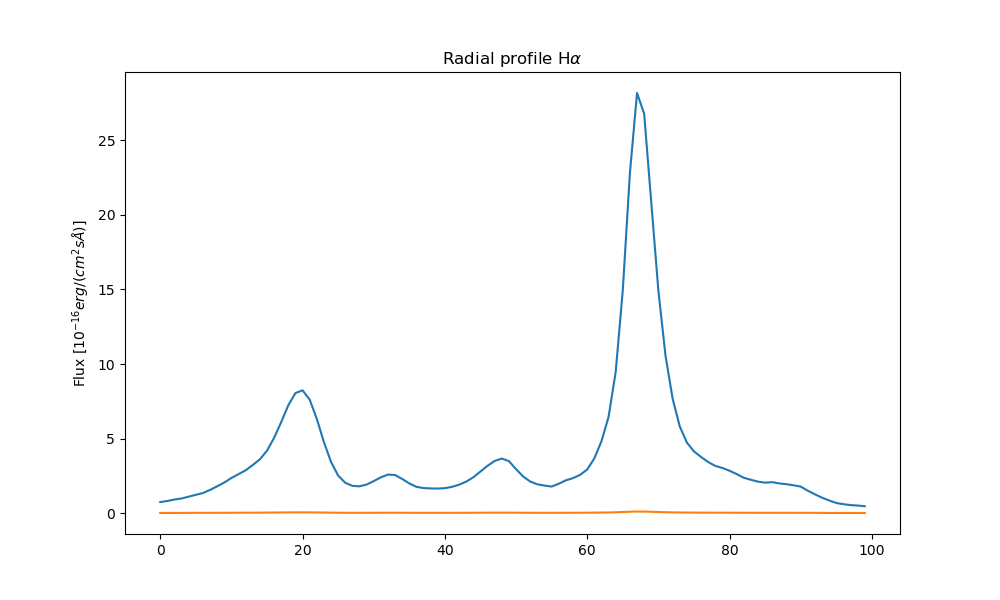

In [14]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

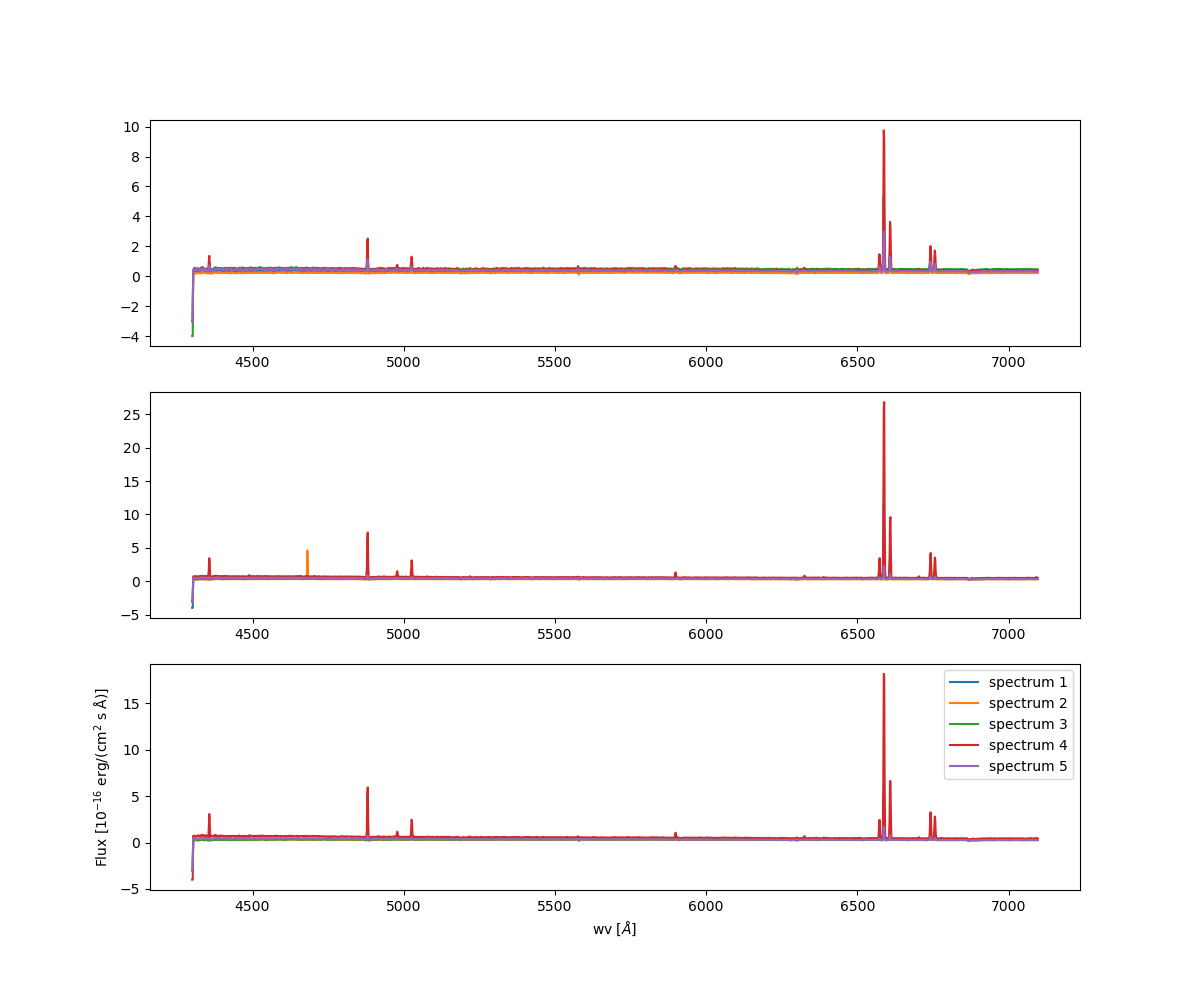

In [15]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/Fit/Halpha_fit.csv", index_col=0)
os.makedirs('1s_center', exist_ok=True)

peaks = fit_HA.iloc[3].values

fig, ax = plt.subplots(3, 1, figsize=(12, 10))
spectra_sx =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_c =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_dx =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_sx = np.zeros((len(peaks), image_error_cut.shape[1]))
spectra_err_c = np.zeros((len(peaks), image_error_cut.shape[1]))
spectra_err_dx = np.zeros((len(peaks), image_error_cut.shape[1]))
data_sx = []
data_c = []
data_dx = []
#colors_sx =  ['lightblue', 'lightgreen', 'thistle', 'bisque', 'violet', ]
#colors_c = ['blue', 'green', 'm', 'orange']
#colors_dx = ['darkblue', 'darkgreen', 'darkmagenta', 'darkorange']

#Cut one sigma 
for i in range(len(peaks)):
    mask_sx = (x_axes > ((peaks[i]-sigma)-2*sigma))*(x_axes < peaks[i]-sigma)
    mask_c = (x_axes > peaks[i]-sigma)*(x_axes < peaks[i]+sigma)
    mask_dx = (x_axes > peaks[i]+sigma)*(x_axes < ((peaks[i]+sigma)+2*sigma))
    spectra_sx[i] = np.sum(image_cut[mask_sx, :], axis = 0)
    spectra_c[i] = np.sum(image_cut[mask_c, :], axis = 0)
    spectra_dx[i] = np.sum(image_cut[mask_dx, :], axis = 0)
    spectra_err_sx[i] = np.sqrt(np.sum(image_error_cut[mask_sx, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    spectra_err_c[i] = np.sqrt(np.sum(image_error_cut[mask_c, :]**2, axis = 0))
    spectra_err_dx[i] = np.sqrt(np.sum(image_error_cut[mask_dx, :]**2, axis = 0))
    ax[0].plot(wv, spectra_sx[i], label = f'spectrum {i+1}')
    ax[1].plot(wv, spectra_c[i], label = f'spectrum {i+1}')
    ax[2].plot(wv, spectra_dx[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table_sx = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_sx[i].reshape(-1, 1), spectra_err_sx[i].reshape(-1, 1)), axis=1)
    spectrum_table_c = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_c[i].reshape(-1, 1), spectra_err_c[i].reshape(-1, 1)), axis=1)
    spectrum_table_dx = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_dx[i].reshape(-1, 1), spectra_err_dx[i].reshape(-1, 1)), axis=1)

    filename_sx = os.path.join('1s_center', f'Spectrum_sx_{i+1}.txt')  
    np.savetxt(filename_sx, spectrum_table_sx)

    filename_center = os.path.join('1s_center', f'Spectrum_center_{i+1}.txt')  
    np.savetxt(filename_center, spectrum_table_c)

    filename_dx = os.path.join('1s_center', f'Spectrum_dx_{i+1}.txt')  
    np.savetxt(filename_dx, spectrum_table_dx)

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [16]:
mask_continuum_1 = (wv > 4400)*(wv < 4650)
mask_continuum_2 = (wv > 5100)*(wv < 5550)
mask_continuum_3 = (wv > 6000)*(wv < 6500)

# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_sx[i, mask_continuum_1])
    noise_1 = np.std(spectra_sx[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_sx[i, mask_continuum_2])
    noise_2 = np.std(spectra_sx[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_sx[i, mask_continuum_3])
    noise_3 = np.std(spectra_sx[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
    
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
os.path.join('1s_center', 'SNR_c_continuum.csv')
df_path_snr = os.path.join('1s_center', 'SNR_sx_continuum.csv')
df_path_signal = os.path.join('1s_center', 'Signal_sx_continuum.csv')
df_path_noise = os.path.join('1s_center', 'Noise_sx_continuum.csv')
df_path_combined = os.path.join('1s_center', 'Combined_sx_continuum.csv')
# Assicurati che la directory esista
os.makedirs('1s_center', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1   14.849547   12.403835   15.399610   19.507152   17.341630
Continuum_2   19.325459   15.750025   18.903257   20.892549   20.118468
Continuum_3   16.916930   14.979396   19.420848   19.656930   18.885140

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.367345    0.235246    0.537732    0.502286    0.460056
Continuum_2    0.321777    0.232874    0.512842    0.458594    0.400047
Continuum_3    0.283575    0.227744    0.489498    0.427449    0.361017

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.024738    0.018966    0.034919    0.025749    0.026529
Continuum_2    0.016650    0.014786    0.027130    0.021950    0.019885
Continuum_3    0.016763    0.015204    0.025205    0.021745    0.019116

DataFrame Combinato:
                   SNR                                        

In [17]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_c[i, mask_continuum_1])
    noise_1 = np.std(spectra_c[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_c[i, mask_continuum_2])
    noise_2 = np.std(spectra_c[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_c[i, mask_continuum_3])
    noise_3 = np.std(spectra_c[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T
# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
df_path_snr = os.path.join('1s_center', 'SNR_c_continuum.csv')
df_path_signal = os.path.join('1s_center', 'Signal_c_continuum.csv')
df_path_noise = os.path.join('1s_center', 'Noise_c_continuum.csv')
df_path_combined = os.path.join('1s_center', 'Combined_c_continuum.csv')
# Assicurati che la directory esista
os.makedirs('1s_center', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1   19.845178   15.214559   14.044636   22.034478   18.775197
Continuum_2   21.344004   18.708640   17.886927   24.374052   21.894826
Continuum_3   18.800260   17.319651   18.171183   16.260390   18.632234

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.583991    0.320943    0.377241    0.724031    0.499542
Continuum_2    0.493861    0.305670    0.370443    0.604770    0.418877
Continuum_3    0.432396    0.291906    0.364238    0.533618    0.359107

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.029427    0.021094    0.026860    0.032859    0.026606
Continuum_2    0.023138    0.016338    0.020710    0.024812    0.019131
Continuum_3    0.022999    0.016854    0.020045    0.032817    0.019273

DataFrame Combinato:
                   SNR                                        

In [18]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_dx[i, mask_continuum_1])
    noise_1 = np.std(spectra_dx[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_dx[i, mask_continuum_2])
    noise_2 = np.std(spectra_dx[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_dx[i, mask_continuum_3])
    noise_3 = np.std(spectra_dx[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T
# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
df_path_snr = os.path.join('1s_center', 'SNR_dx_continuum.csv')
df_path_signal = os.path.join('1s_center', 'Signal_dx_continuum.csv')
df_path_noise = os.path.join('1s_center', 'Noise_dx_continuum.csv')
df_path_combined = os.path.join('1s_center', 'Combined_dx_continuum.csv')
# Assicurati che la directory esista
os.makedirs('1s_center', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1   16.371234   13.612111   13.701784   22.141838   18.342030
Continuum_2   19.061050   16.677968   16.785681   24.089539   20.930952
Continuum_3   17.376456   17.158467   19.470968   16.509031   17.277355

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.383225    0.322171    0.332092    0.696850    0.448897
Continuum_2    0.330668    0.311485    0.339751    0.577611    0.370173
Continuum_3    0.293557    0.296484    0.337697    0.491096    0.312123

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.023408    0.023668    0.024237    0.031472    0.024474
Continuum_2    0.017348    0.018676    0.020241    0.023978    0.017685
Continuum_3    0.016894    0.017279    0.017344    0.029747    0.018065

DataFrame Combinato:
                   SNR                                        

## S/N emission lines 

In [19]:
def SNR_line(wv, wv_line, spectra, peaks):
    left_region = (wv > wv_line-25)*(wv < wv_line-10) 
    right_region = (wv > wv_line+10)*(wv < wv_line+25) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise 

def SNR_SII_line(wv, wv_line, spectra, peaks):
    left_region = (wv > 6737-15)*(wv < 6737) 
    right_region = (wv > 6762)*(wv < 6762+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, wv_line, spectra, peaks):
    left_region = (wv > 6566-15) & (wv < 6566)
    right_region = (wv > 6615) & (wv < 6615+15)
    clean_mask = left_region | right_region #But also for the two NII lines bc they are closed

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))

    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 

In [20]:
index = ['Component_1', 'Component_2', 'Component_3', 'Component_4', 'Component_5']
SNR_HB_1, signal_HB_1, noise_HB_1 = SNR_line(wv, l_HB, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_HB_1).reshape(-1, 1),
    np.array(signal_HB_1).reshape(-1, 1),
    np.array(noise_HB_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index )
df_path = os.path.join('1s_center', 'SNR_HB_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_2, signal_HB_2, noise_HB_2 = SNR_line(wv, l_HB, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_HB_2).reshape(-1, 1),
    np.array(signal_HB_2).reshape(-1, 1),
    np.array(noise_HB_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_HB_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_3, signal_HB_3, noise_HB_3 = SNR_line(wv, l_HB, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_HB_3).reshape(-1, 1),
    np.array(signal_HB_3).reshape(-1, 1),
    np.array(noise_HB_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_HB_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_1, signal_SII_1, noise_SII_1 = SNR_SII_line(wv, l_SII_1, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_SII_1).reshape(-1, 1),
    np.array(signal_SII_1).reshape(-1, 1),
    np.array(noise_SII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_1_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2, signal_SII_2, noise_SII_2 = SNR_SII_line(wv, l_SII_1, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_SII_2).reshape(-1, 1),
    np.array(signal_SII_2).reshape(-1, 1),
    np.array(noise_SII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_1_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_3, signal_SII_3, noise_SII_3 = SNR_SII_line(wv, l_SII_1, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_SII_3).reshape(-1, 1),
    np.array(signal_SII_3).reshape(-1, 1),
    np.array(noise_SII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_1_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_1, signal_SII_2_1, noise_SII_2_1 = SNR_SII_line(wv, l_SII_2, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_1).reshape(-1, 1),
    np.array(signal_SII_2_1).reshape(-1, 1),
    np.array(noise_SII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_2_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_2, signal_SII_2_2, noise_SII_2_2 = SNR_SII_line(wv, l_SII_2, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_2).reshape(-1, 1),
    np.array(signal_SII_2_2).reshape(-1, 1),
    np.array(noise_SII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_2_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_3, signal_SII_2_3, noise_SII_2_3 = SNR_SII_line(wv, l_SII_2, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_3).reshape(-1, 1),
    np.array(signal_SII_2_3).reshape(-1, 1),
    np.array(noise_SII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_2_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_1, signal_OIII_1, noise_OIII_1 = SNR_line(wv, l_OIII_1, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_1).reshape(-1, 1),
    np.array(signal_OIII_1).reshape(-1, 1),
    np.array(noise_OIII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_1_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2, signal_OIII_2, noise_OIII_2 = SNR_line(wv, l_OIII_1, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2).reshape(-1, 1),
    np.array(signal_OIII_2).reshape(-1, 1),
    np.array(noise_OIII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_1_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_3, signal_OIII_3, noise_OIII_3 = SNR_line(wv, l_OIII_1, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_3).reshape(-1, 1),
    np.array(signal_OIII_3).reshape(-1, 1),
    np.array(noise_OIII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_1_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_1, signal_OIII_2_1, noise_OIII_2_1 = SNR_line(wv, l_OIII_2, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_1).reshape(-1, 1),
    np.array(signal_OIII_2_1).reshape(-1, 1),
    np.array(noise_OIII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_2_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_2, signal_OIII_2_2, noise_OIII_2_2 = SNR_line(wv, l_OIII_2, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_2).reshape(-1, 1),
    np.array(signal_OIII_2_2).reshape(-1, 1),
    np.array(noise_OIII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_2_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_3, signal_OIII_2_3, noise_OIII_2_3 = SNR_line(wv, l_OIII_2, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_3).reshape(-1, 1),
    np.array(signal_OIII_2_3).reshape(-1, 1),
    np.array(noise_OIII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_2_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_1, signal_HA_1, noise_HA_1 = SNR_HA_NII(wv, l_HA, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_HA_1).reshape(-1, 1),
    np.array(signal_HA_1).reshape(-1, 1),
    np.array(noise_HA_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_HA_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_2, signal_HA_2, noise_HA_2 = SNR_HA_NII(wv, l_HA, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_HA_2).reshape(-1, 1),
    np.array(signal_HA_2).reshape(-1, 1),
    np.array(noise_HA_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_HA_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_3, signal_HA_3, noise_HA_3 = SNR_HA_NII(wv, l_HA, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_HA_3).reshape(-1, 1),
    np.array(signal_HA_3).reshape(-1, 1),
    np.array(noise_HA_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_HA_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_1, signal_NII_1, noise_NII_1 = SNR_HA_NII(wv, l_NII_1, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_NII_1).reshape(-1, 1),
    np.array(signal_NII_1).reshape(-1, 1),
    np.array(noise_NII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_1_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2, signal_NII_2, noise_NII_2 = SNR_HA_NII(wv, l_NII_1, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_NII_2).reshape(-1, 1),
    np.array(signal_NII_2).reshape(-1, 1),
    np.array(noise_NII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_1_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_3, signal_NII_3, noise_NII_3 = SNR_HA_NII(wv, l_NII_1, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_NII_3).reshape(-1, 1),
    np.array(signal_NII_3).reshape(-1, 1),
    np.array(noise_NII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_1_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_1, signal_NII_2_1, noise_NII_2_1 = SNR_HA_NII(wv, l_NII_2, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_1).reshape(-1, 1),
    np.array(signal_NII_2_1).reshape(-1, 1),
    np.array(noise_NII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_2_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_2, signal_NII_2_2, noise_NII_2_2 = SNR_HA_NII(wv, l_NII_2, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_2).reshape(-1, 1),
    np.array(signal_NII_2_2).reshape(-1, 1),
    np.array(noise_NII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_2_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_3, signal_NII_2_3, noise_NII_2_3 = SNR_HA_NII(wv, l_NII_2, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_3).reshape(-1, 1),
    np.array(signal_NII_2_3).reshape(-1, 1),
    np.array(noise_NII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_2_dx.csv')
df.to_csv(df_path, float_format='%.3f')

In [21]:
peaks

array([19.5   , 32.7029, 47.5338, 67.4752, 79.7322])